# Neuron subset scvi + recluster

* Consider DE testing of the dual innervating cells vs all cells
* What percentile total_counts are the dual innervating cells?


In [1]:
import os
from pathlib import Path
import scanpy as sc
from scipy.sparse import issparse, csr_matrix
import scvi
import numpy as np
from collections import Counter
import anndata as ad
import matplotlib.pyplot as plt
from lightning.pytorch import seed_everything
import random
import torch
import sys
import session_info

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
random.seed(0)
seed_everything(0)

scvi.settings.seed = 0
scvi.settings.num_workers = 32

Seed set to 0
Seed set to 0


In [3]:
plt.rcParams['figure.figsize'] = (3, 3)
#plt.rcParams['figure.dpi'] = 300

In [4]:
base_dir = Path('/home/workspace/projects/drg')

input_dir = base_dir / "data/h5ad/export_03/01_broad-labels"
output_dir = base_dir / "data/h5ad/export_03/02_neuron-labels"
scvi_dir = base_dir / 'scvi/neuron_model'
clusters_dir = os.path.join(base_dir, 'clusters')

scvi_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

## Read data

In [5]:
adata = sc.read_h5ad(os.path.join(input_dir, 'ModelB_whole_noTG_neurons.h5ad'))
adata

AnnData object with n_obs × n_vars = 37176 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'nuclear_fraction', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'scvi_model', 'leiden_scVI_1', 'cell_class'
    var: 'Ensembl ID', 'Probesets', 'zhen_list', 'spectral_panel', 'neurons_supervised', 'neurons_unsupervised', 'glia_supervised', 'glia_unsupervised', 'other', 'neuron_DEGs', 'neuron_detection_rate', 'glia_detection_rate', 'combined_detection_rate_mean'
    uns: '_scvi_manager_uuid',

In [6]:
adata.var

,Ensembl ID,Probesets,zhen_list,spectral_panel,neurons_supervised,neurons_unsupervised,glia_supervised,glia_unsupervised,other,neuron_DEGs,neuron_detection_rate,glia_detection_rate,combined_detection_rate_mean
1500009L16Rik,ENSMUSG00000087651,8,False,False,True,False,False,False,False,False,27.775189,1.959862,14.867525
6330403K07Rik,ENSMUSG00000018451,8,False,False,False,False,False,False,False,True,68.244944,5.809031,37.026987
Abcb1a,ENSMUSG00000040584,8,False,False,False,False,False,False,True,False,0.960015,15.004704,7.982359
Ache,ENSMUSG00000023328,8,False,False,False,False,False,False,True,False,18.361450,0.901537,9.631493
Acta2,ENSMUSG00000035783,5,False,False,False,False,False,False,True,False,0.466027,1.583569,1.024798
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vat1l,ENSMUSG00000046844,8,False,False,False,False,False,False,False,True,37.776121,5.091722,21.433921
Vip,ENSMUSG00000019772,8,False,False,False,False,False,False,True,False,0.000000,0.003920,0.001960
Vwf,ENSMUSG00000001930,8,False,False,False,False,False,False,True,False,0.615155,3.696300,2.155727
Wfdc18,ENSMUSG00000000983,6,False,False,False,False,False,True,False,False,0.233013,2.826121,1.529567


## Subset adata.var

In [7]:
cols = ["zhen_list", "neurons_supervised", "neurons_unsupervised", "neuron_DEGs"]

truthy_values = {"true", "t", "yes", "y", "1"}

for c in cols:
    adata.var[c] = (
        adata.var[c]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(truthy_values)
    )

In [8]:
for c in cols:
    print(f"{c}: {adata.var[c].sum()} True")

zhen_list: 122 True
neurons_supervised: 49 True
neurons_unsupervised: 17 True
neuron_DEGs: 24 True


In [9]:
cols = ["zhen_list", "neurons_supervised", "neurons_unsupervised", "neuron_DEGs"]

mask = adata.var[cols].any(axis=1)

genes_keep = adata.var_names[mask]
print(f"Selected {mask.sum()} genes")

adata = adata[:, mask].copy()
adata

Selected 212 genes


AnnData object with n_obs × n_vars = 37176 × 212
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'nuclear_fraction', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'scvi_model', 'leiden_scVI_1', 'cell_class'
    var: 'Ensembl ID', 'Probesets', 'zhen_list', 'spectral_panel', 'neurons_supervised', 'neurons_unsupervised', 'glia_supervised', 'glia_unsupervised', 'other', 'neuron_DEGs', 'neuron_detection_rate', 'glia_detection_rate', 'combined_detection_rate_mean'
    uns: '_scvi_manager_uuid',

In [10]:
adata.var

,Ensembl ID,Probesets,zhen_list,spectral_panel,neurons_supervised,neurons_unsupervised,glia_supervised,glia_unsupervised,other,neuron_DEGs,neuron_detection_rate,glia_detection_rate,combined_detection_rate_mean
1500009L16Rik,ENSMUSG00000087651,8,False,False,True,False,False,False,False,False,27.775189,1.959862,14.867525
6330403K07Rik,ENSMUSG00000018451,8,False,False,False,False,False,False,False,True,68.244944,5.809031,37.026987
Adcyap1,ENSMUSG00000024256,8,True,False,False,False,False,False,False,False,36.862709,0.889777,18.876243
Adgrg2,ENSMUSG00000031298,8,False,False,True,False,False,False,False,False,23.254730,1.117121,12.185926
Adra2a,ENSMUSG00000033717,8,True,False,False,False,False,False,False,False,4.809395,0.646754,2.728075
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Unc5c,ENSMUSG00000059921,8,False,False,True,False,False,False,False,False,10.774536,0.537002,5.655769
Upb1,ENSMUSG00000033427,8,False,False,False,True,False,False,False,False,13.757107,0.356695,7.056901
Vamp1,ENSMUSG00000030337,8,False,False,True,False,False,False,False,False,48.960761,8.815459,28.888110
Vat1l,ENSMUSG00000046844,8,False,False,False,False,False,False,False,True,37.776121,5.091722,21.433921


In [11]:
adata.obs.output_id

aaagciof-1-0    TMA00303
aaailodo-1-0    TMA00303
aaanacfp-1-0    TMA00303
aaaohjeo-1-0    TMA00303
aabfmjal-1-0    TMA00303
                  ...   
ojabjopo-1-3    TMA00306
ojbjiocj-1-3    TMA00306
ojbnljfj-1-3    TMA00306
ojbojfpi-1-3    TMA00306
ojcapmap-1-3    TMA00306
Name: output_id, Length: 37176, dtype: category
Categories (4, object): ['TMA00303', 'TMA00304', 'TMA00305', 'TMA00306']

## Prepare adata

In [12]:
adata.X[:5, :5].toarray()

array([[0.      , 8.659507, 0.      , 0.      , 0.      ],
       [7.125473, 9.021909, 6.028468, 9.491867, 6.028468],
       [6.24855 , 6.24855 , 6.24855 , 8.326299, 0.      ],
       [0.      , 7.644289, 0.      , 0.      , 0.      ],
       [0.      , 9.205453, 0.      , 8.512406, 0.      ]], dtype=float32)

In [13]:
# Save counts layer for scVI and downstream processing
adata.X = adata.layers["counts"].copy()

print('adata.X is sparse:', issparse(adata.X))
print('adata.X has only whole numbers:', np.all(adata.X.data == np.round(adata.X.data)))  # True if all values are whole numbers

adata.X is sparse: True
adata.X has only whole numbers: True


In [14]:
adata.X[:5, :5].toarray()

array([[ 0.,  2.,  0.,  0.,  0.],
       [ 3., 20.,  1., 32.,  1.],
       [ 1.,  1.,  1.,  8.,  0.],
       [ 0.,  1.,  0.,  0.,  0.],
       [ 0.,  4.,  0.,  2.,  0.]], dtype=float32)

In [74]:
print("adata.X shape:", adata.X.shape)

if "counts" in adata.layers:
    print("adata.layers['counts'] shape:", adata.layers["counts"].shape)
else:
    print("'counts' layer not found in adata.layers")

adata.X shape: (37176, 212)
adata.layers['counts'] shape: (37176, 212)


## scVI

#### Train model

In [15]:
# Set up AnnData for SCVI
scvi.model.SCVI.setup_anndata(
    adata, 
    layer="counts",  # Use raw count data
    batch_key = 'slide'
)

/home/workspace/environment/sc-charter/lib/python3.12/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


In [16]:
# Initialize model
model = scvi.model.SCVI(
    adata,
    n_layers=2,  # Two-layer neural network
    n_latent=30,  # Latent space size
    gene_likelihood = "nb" # TRM paper
)

In [17]:
# Train SCVI with updated parameters
model.train(
    early_stopping=True,
    accelerator = "gpu",
    early_stopping_patience=5,  # Stop if no improvement for 5 epochs
    early_stopping_min_delta=1e-4,  # Require small improvement to continue
    enable_progress_bar=True
)

Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a

Epoch 215/215: 100%|██████████| 215/215 [08:36<00:00,  2.44s/it, v_num=1, train_loss_step=207, train_loss_epoch=213]

`Trainer.fit` stopped: `max_epochs=215` reached.


Epoch 215/215: 100%|██████████| 215/215 [08:36<00:00,  2.40s/it, v_num=1, train_loss_step=207, train_loss_epoch=213]


In [21]:
scvi_dir = base_dir / 'scvi/neuron_model'

In [22]:
model.save(scvi_dir, prefix='02_neuron_scvi_')

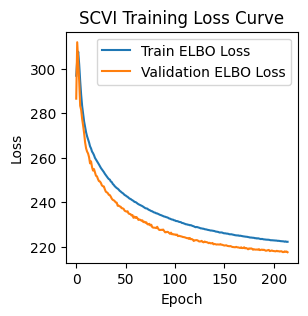

In [23]:
plt.plot(model.history["elbo_train"], label="Train ELBO Loss")
plt.plot(model.history["elbo_validation"], label="Validation ELBO Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("SCVI Training Loss Curve")
plt.show()

## Extract latent representation, save

In [24]:
# add scVI latent dimensions to adata.obsm
adata.obsm['X_scVI_neuron'] = model.get_latent_representation(adata).astype(np.float32)
adata.obsm['X_scVI_neuron'].shape

(37176, 30)

## Neighbors, UMAP, clustering

In [25]:
sc.pp.neighbors(adata, use_rep = 'X_scVI_neuron', random_state = 0)

In [26]:
sc.tl.umap(adata, random_state = 0)

In [75]:
sc.tl.leiden(adata, key_added='neuron_cluster', resolution=0.4)

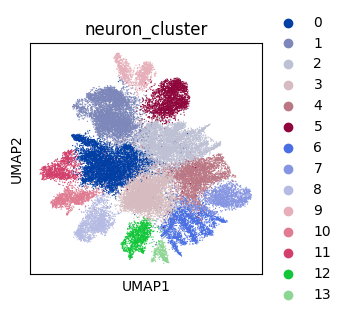

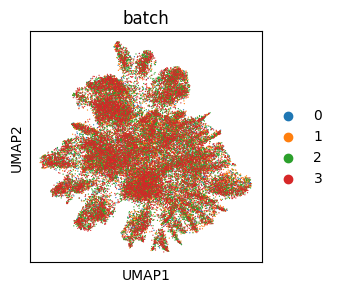

In [76]:
sc.pl.umap(adata, color = ['neuron_cluster'], legend_fontsize = 10)
sc.pl.umap(adata, color = ['batch'], legend_fontsize = 10)

### Run DE rankings on clusters

In [77]:
adata.X = adata.layers["log1p"].copy()


In [78]:
# performance warning here but should be fine

sc.tl.rank_genes_groups(adata, groupby='neuron_cluster', method='wilcoxon', use_raw = False)
df = sc.get.rank_genes_groups_df(adata, group = None)
df = df.copy()
df = df[(df.pvals_adj < 0.05) & (df.logfoldchanges > .5)].copy()
df.head(5)

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,Tac1,104.445023,7.083575,0.0,0.0
1,0,Gpx3,100.307625,8.922702,0.0,0.0
2,0,Gfra3,97.373962,9.158079,0.0,0.0
3,0,Trpv1,95.323212,7.885190,0.0,0.0
4,0,6330403K07Rik,95.085976,5.598080,0.0,0.0


In [79]:
clusters_path = os.path.join(clusters_dir, 'rank-genes-clusters_neuron.csv')

df.to_csv(clusters_path, index=False)
print(clusters_path)

/home/workspace/projects/drg/clusters/rank-genes-clusters_neuron.csv


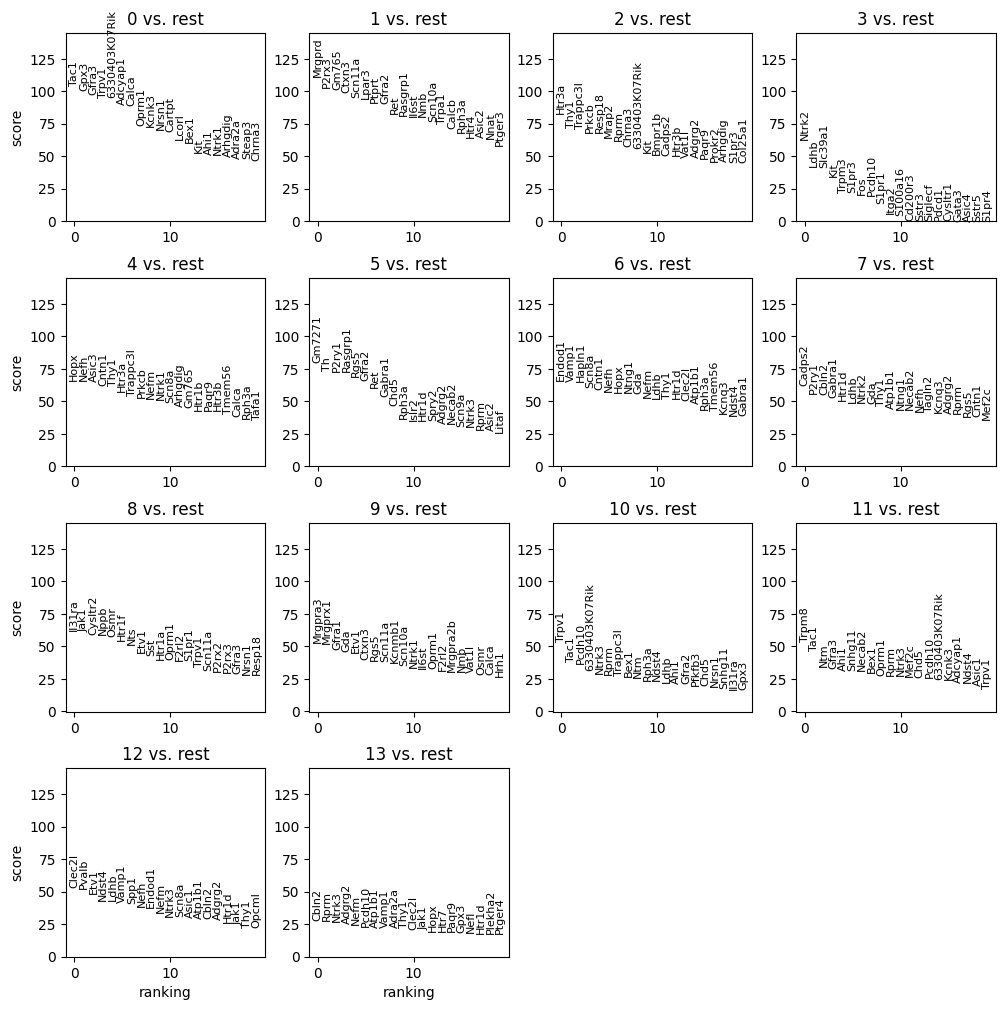

In [80]:
# Visualize top results
sc.pl.rank_genes_groups(adata, groupby = 'neuron_cluster', method = 'wilcoxon', use_raw = False)

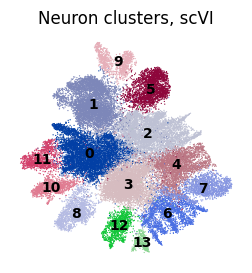

In [81]:
#import seaborn as sns
sc.pl.umap(adata, color = 'neuron_cluster', legend_loc = 'on data', frameon = False, title = 'Neuron clusters, scVI')

Found in adata: ['bpoikicj-1-1', 'akcoadof-1-2', 'bgmdeeeb-1-2', 'hjjgalia-1-2', 'bmjgagok-1-3', 'ijnggkoc-1-3']


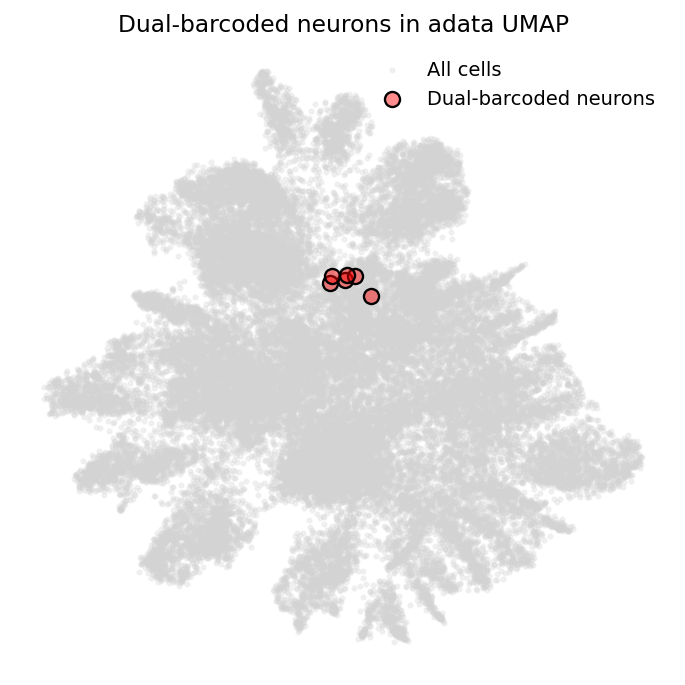

In [82]:
# List of barcoded neurons
dual_barcodes = [
    'bpoikicj-1-1',
    'akcoadof-1-2',
    'bgmdeeeb-1-2',
    'hjjgalia-1-2',
    'bmjgagok-1-3',
    'ijnggkoc-1-3'
]

# Make sure these exist in adata
dual_mask = adata.obs_names.isin(dual_barcodes)

print("Found in adata:", adata.obs_names[dual_mask].tolist())

# Convert barcodes to integer indices
dual_indices = [adata.obs_names.get_loc(cell) for cell in adata.obs_names[dual_mask]]

# UMAP coordinates
umap = adata.obsm["X_umap"]

# Visualization
plt.figure(figsize=(5,5), dpi=140)

# Background cells
plt.scatter(
    umap[:, 0],
    umap[:, 1],
    c="lightgray",
    s=5, alpha=0.25,
    label="All cells"
)

# Highlight dual-barcoded neurons
plt.scatter(
    umap[dual_indices, 0],
    umap[dual_indices, 1],
    s=60,
    facecolors=(1, 0, 0, 0.45),  # translucent red fill
    edgecolors="black",
    linewidths=1.2,
    marker="o",
    label="Dual-barcoded neurons"
)

plt.title("Dual-barcoded neurons in adata UMAP")
plt.xticks([]); plt.yticks([])
plt.legend(frameon=False)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

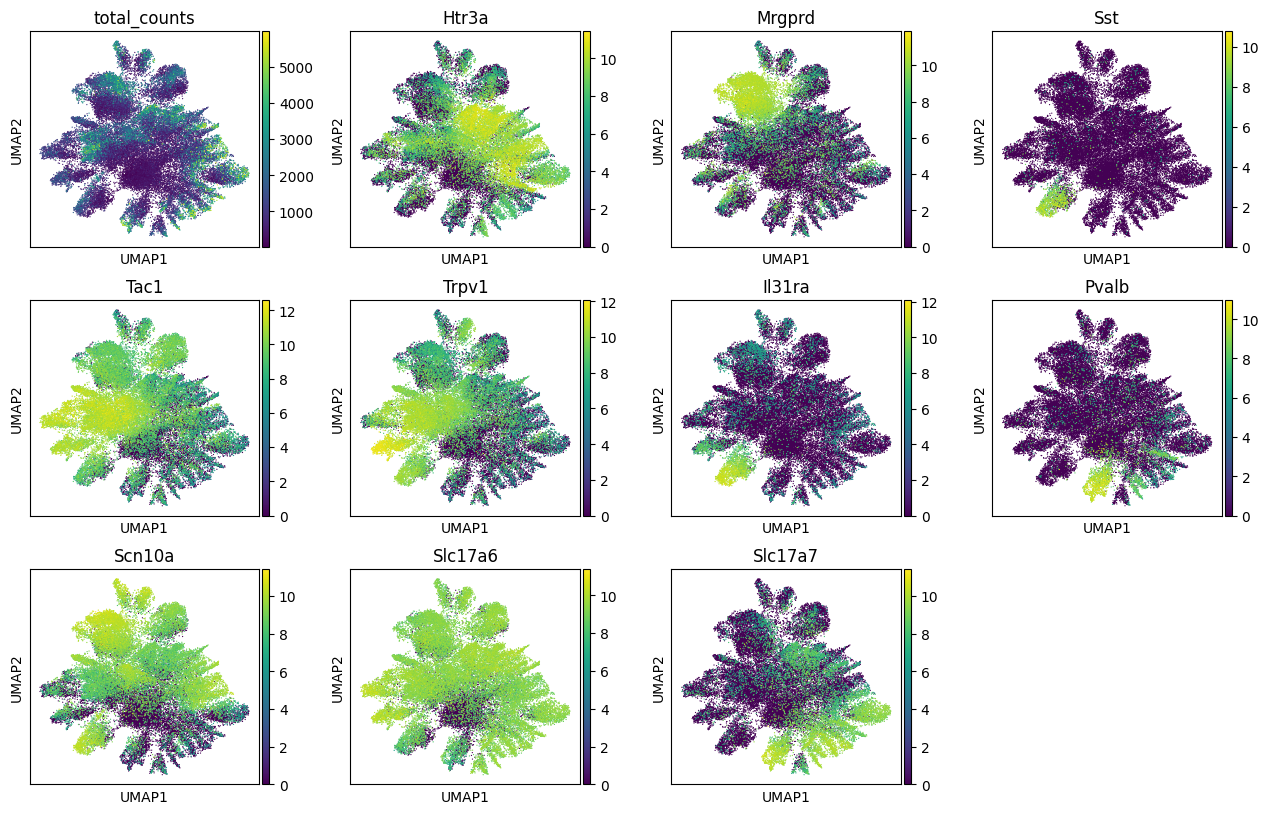

In [84]:
sc.pl.umap(adata,
           color = ['total_counts', 'Htr3a', 'Mrgprd', 'Sst', 'Tac1', 'Trpv1', 'Il31ra', 'Pvalb', 'Scn10a', 'Slc17a6', 'Slc17a7'])


 Dual-barcoded neuron cluster assignments
bpoikicj-1-1         > 2
akcoadof-1-2         > 2
bgmdeeeb-1-2         > 2
hjjgalia-1-2         > 2
bmjgagok-1-3         > 2
ijnggkoc-1-3         > 2

 Summary: counts per cluster
neuron_cluster
2     6
0     0
1     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
Name: count, dtype: int64


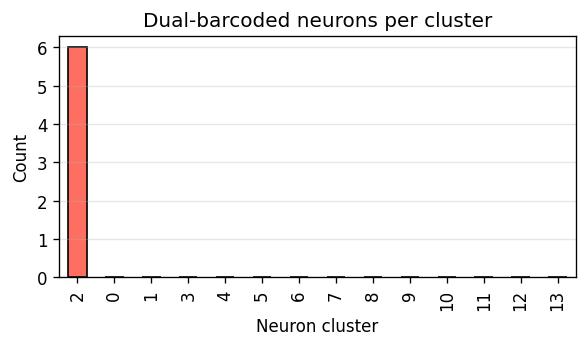

In [83]:
# --- Cluster summary for dual-barcoded neurons ---

if "neuron_cluster" in adata.obs.columns:
    clusters = adata.obs.loc[dual_mask, "neuron_cluster"]

    print("\n Dual-barcoded neuron cluster assignments")
    for cell, cluster in zip(adata.obs_names[dual_mask], clusters):
        print(f"{cell:<20} > {cluster}")

    # Summarize counts by cluster
    cluster_counts = clusters.value_counts()
    print("\n Summary: counts per cluster")
    print(cluster_counts)

    # Optional quick visualization
    plt.figure(figsize=(5,3), dpi=120)
    cluster_counts.plot(kind="bar", color="#ff6f61", edgecolor="black")
    plt.title("Dual-barcoded neurons per cluster")
    plt.ylabel("Count")
    plt.xlabel("Neuron cluster")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\nColumn 'neuron_cluster' not found in adata.obs")

## Export

In [85]:
filename = os.path.join(output_dir, 'neuron-scvi.h5ad')
os.makedirs(os.path.dirname(filename), exist_ok=True)

adata.write_h5ad(filename, compression='gzip')

## Session info

In [86]:
print('active IDE: sc-spatial-gpu')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-spatial-gpu
active conda environment: sc-charter


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


In [ ]:
print('active IDE: sc-spatial-gpu')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()